# Compact CIFAR-10 GAN in PyTorch

In [2]:
# ------------------------------------------------------------
# Imports and device setup
# ------------------------------------------------------------
# We import only the libraries needed to train a small GAN and
# visualize progress inside the notebook.

import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision.models import Inception_V3_Weights, inception_v3
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

In [3]:
# Use a fixed seed so that runs are more reproducible.
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Choose the fastest available device in a laptop-friendly order.
# CUDA is preferred for NVIDIA GPUs, then Apple's MPS backend,
# and finally CPU if no accelerator is available.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: cpu


In [4]:
# ------------------------------------------------------------
# Hyperparameters and output paths
# ------------------------------------------------------------

DATA_DIR = "data"
OUTPUT_DIR = Path("cifar10_gan_runs_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 10
BATCH_SIZE = 64
LATENT_DIM = 128
# Set the GAN learning rate
LEARNING_RATE = 0.002
BETAS = (0.5, 0.999)

NUM_WORKERS = 0

# Use only part of the dataset if you want faster experiments.
# 1.0 means the full 50,000 CIFAR-10 training images.
DATASET_FRACTION = 0.5

# Save progress periodically so training can be monitored visually.
SAMPLE_EVERY = 5
CHECKPOINT_EVERY = 10
METRICS_PATH = OUTPUT_DIR / "metrics.csv"

# FID evaluation is more expensive than a single training epoch, so we
# score a moderate number of images by default.
FID_NUM_IMAGES = 5000
FID_BATCH_SIZE = 128

print("Outputs will be saved to:", OUTPUT_DIR.resolve())

Outputs will be saved to: C:\Users\sarah\Downloads\data science 2\cifar10_gan_runs_notebook


In [5]:
# ------------------------------------------------------------
# Load CIFAR-10 and build the DataLoader
# ------------------------------------------------------------
# CIFAR-10 images are 32x32 RGB images, which makes them a good fit
# for a small convolutional GAN.
#
# We normalize image values from [0, 1] to [-1, 1] because the
# generator ends with a tanh activation, which also outputs values
# in [-1, 1]. Matching those ranges helps training behave properly.

if not 0.0 < DATASET_FRACTION <= 1.0:
    raise ValueError("DATASET_FRACTION must be between 0 and 1.")

transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

# Optionally train on a smaller, random subset for faster iteration.
if DATASET_FRACTION < 1.0:
    # Your codes start here ------------------------------------------------------
    subset_size = max(1, int(len(train_dataset) * DATASET_FRACTION))
    subset_generator = torch.Generator().manual_seed(SEED)
    subset_indices = torch.randperm(len(train_dataset), generator=subset_generator)[:subset_size]
    train_dataset = Subset(train_dataset, subset_indices.tolist())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
    persistent_workers=(NUM_WORKERS > 0),
)

print("Number of training batches:", len(train_loader))

Number of training batches: 390


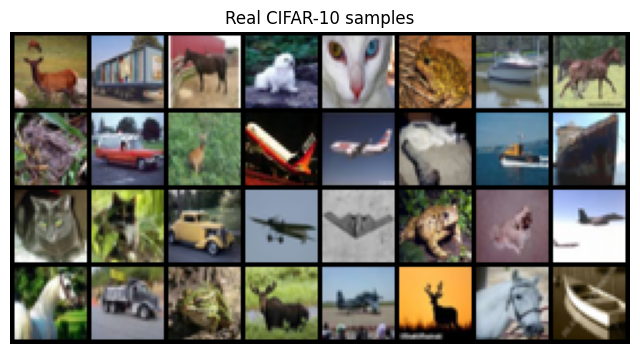

In [6]:
# ------------------------------------------------------------
# Visualize a batch of real CIFAR-10 images
# ------------------------------------------------------------
# Looking at a real batch helps verify that the dataset pipeline and
# normalization are working as expected.

real_batch, _ = next(iter(train_loader))

# make_grid combines several images into one display image.
grid = make_grid(real_batch[:32], nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Real CIFAR-10 samples")
plt.show()

In [7]:
# ------------------------------------------------------------
# Define the discriminator
# ------------------------------------------------------------
#
# Discriminator:
# - Takes a 32x32 RGB image.
# - Repeatedly downsamples with strided convolutions.
# - Outputs one realism score for each image.


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Each strided convolution halves the spatial resolution:
        # 32x32 -> 16x16 -> 8x8 -> 4x4.
        self.conv1 = nn.Conv2d(3, 48, kernel_size=4, stride=2, padding=1, bias=False)
        self.conv1_activation = nn.LeakyReLU(0.2, inplace=True)

        self.conv2 = nn.Conv2d(48, 96, kernel_size=4, stride=2, padding=1, bias=False)
        self.conv2_bn = nn.BatchNorm2d(96)
        self.conv2_activation = nn.LeakyReLU(0.2, inplace=True)

        # Your codes start here ---------------------------------------------------------
        # Define the third convolutional layer
        self.conv3 = nn.Conv2d(96, 192, kernel_size=4, stride=2, padding=1, bias=False)
        self.conv3_bn = nn.BatchNorm2d(192)
        self.conv3_activation = nn.LeakyReLU(0.2, inplace=True)

        self.output_layer = nn.Conv2d(192, 1, kernel_size=4, stride=1, padding=0, bias=False)

    def forward(self, images):
        # Process the image one block at a time so the downsampling path
        # is explicit and easy to inspect.
        features = self.conv1(images)
        features = self.conv1_activation(features)

        features = self.conv2(features)
        features = self.conv2_bn(features)
        features = self.conv2_activation(features)

        # Your codes start here ---------------------------------------------------------
        # Define the third convolutional layer
        features = self.conv3(features)
        features = self.conv3_bn(features)
        features = self.conv3_activation(features)

        # The final output is one score per image.
        logits = self.output_layer(features)
        return logits.view(-1, 1)

In [8]:
# ------------------------------------------------------------
# Define the generator
# ------------------------------------------------------------

# Generator:
# - Starts from a random latent vector.
# - Expands that vector into a small 4x4 feature map.
# - Uses transposed convolutions to upsample to 32x32 RGB images.

class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # The initial hidden width is small enough for laptops but
        # still expressive enough to model CIFAR-10 reasonably.
        # First map the noise vector into a dense feature representation.
        # After reshaping, it becomes a stack of 4x4 feature maps.
        self.projection = nn.Linear(latent_dim, 192 * 4 * 4)
        self.projection_bn = nn.BatchNorm1d(192 * 4 * 4)
        self.projection_activation = nn.ReLU(inplace=True)

        # Each transposed convolution doubles the spatial resolution:
        # 4x4 -> 8x8 -> 16x16 -> 32x32.
        self.deconv1 = nn.ConvTranspose2d(192, 96, kernel_size=4, stride=2, padding=1, bias=False)
        self.deconv1_bn = nn.BatchNorm2d(96)
        self.deconv1_activation = nn.ReLU(inplace=True)

        # Your codes start here ---------------------------------------------------------
        # Define the operations of the second deconvolutional layer
        self.deconv2 = nn.ConvTranspose2d(96, 48, kernel_size=4, stride=2, padding=1, bias=False)
        self.deconv2_bn = nn.BatchNorm2d(48)
        self.deconv2_activation = nn.ReLU(inplace=True)

        self.output_layer = nn.ConvTranspose2d(48, 3, kernel_size=4, stride=2, padding=1, bias=False)
        self.output_activation = nn.Tanh()

    def forward(self, noise):
        # First transform the latent vector into a learned feature space.
        features = self.projection(noise)
        features = self.projection_bn(features)
        features = self.projection_activation(features)

        # Convert the flat vector into a 4D tensor expected by
        # convolutional layers: [batch, channels, height, width].
        features = features.view(noise.size(0), 192, 4, 4)

        # Upsample step by step so the spatial growth is explicit.
        features = self.deconv1(features)
        features = self.deconv1_bn(features)
        features = self.deconv1_activation(features)

        # Your codes start here ---------------------------------------------------------
        # Define the operations of the second deconvolutional layer
        features = self.deconv2(features)
        features = self.deconv2_bn(features)
        features = self.deconv2_activation(features)

        features = self.output_layer(features)
        return self.output_activation(features)




In [9]:
# ------------------------------------------------------------
# Initialize model weights and create the networks
# ------------------------------------------------------------
# DCGAN-style weight initialization often helps GAN training become
# more stable early on.

def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if getattr(module, "bias", None) is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
        nn.init.normal_(module.weight, mean=1.0, std=0.02)
        nn.init.zeros_(module.bias)


generator = Generator(LATENT_DIM).to(DEVICE)
discriminator = Discriminator().to(DEVICE)

generator.apply(init_weights)
discriminator.apply(init_weights)

# Your codes start here ------------------------------------------------------
# Use binary cross-entropy with logits for GAN training
criterion = nn.BCEWithLogitsLoss()

# Adam with beta1=0.5 is a common GAN default because it usually gives
# smoother optimization than standard momentum settings.
g_optimizer = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=BETAS)

print(generator)
print()
print(discriminator)

Generator(
  (projection): Linear(in_features=128, out_features=3072, bias=True)
  (projection_bn): BatchNorm1d(3072, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (projection_activation): ReLU(inplace=True)
  (deconv1): ConvTranspose2d(192, 96, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (deconv1_bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv1_activation): ReLU(inplace=True)
  (deconv2): ConvTranspose2d(96, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (deconv2_bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv2_activation): ReLU(inplace=True)
  (output_layer): ConvTranspose2d(48, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (output_activation): Tanh()
)

Discriminator(
  (conv1): Conv2d(3, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv1_activation): LeakyReLU(negative_slope=0.2, i

In [10]:
# ------------------------------------------------------------
# Helpers for saving and displaying generated samples
# ------------------------------------------------------------
# We keep one fixed set of noise vectors so that sample images can be
# compared across epochs. This makes progress easier to judge.

# Your codes start here ------------------------------------------------------
# Create fixed noise for visualizing generator progress
FIXED_NOISE = torch.randn(64, LATENT_DIM, device=DEVICE)


def save_sample_grid(epoch):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(FIXED_NOISE).cpu()

    sample_path = OUTPUT_DIR / f"samples_epoch_{epoch:03d}.png"
    save_image(fake_images, sample_path, nrow=8, normalize=True, value_range=(-1, 1))
    generator.train()
    return sample_path


def show_latest_samples(epoch):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(FIXED_NOISE).cpu()

    grid = make_grid(fake_images, nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"Generated samples at epoch {epoch}")
    plt.show()
    generator.train()


# Save and preview the generator's output before training.
initial_sample_path = save_sample_grid(epoch=0)
print("Saved initial samples to:", initial_sample_path)
# show_latest_samples(epoch=0)

Saved initial samples to: cifar10_gan_runs_notebook\samples_epoch_000.png


Epoch 001/10 | G loss: 2.2072 | D loss: 0.6224
Epoch 002/10 | G loss: 1.9889 | D loss: 0.5745
Epoch 003/10 | G loss: 2.0950 | D loss: 0.5523
Epoch 004/10 | G loss: 1.9816 | D loss: 0.5607
Epoch 005/10 | G loss: 1.8540 | D loss: 0.5624


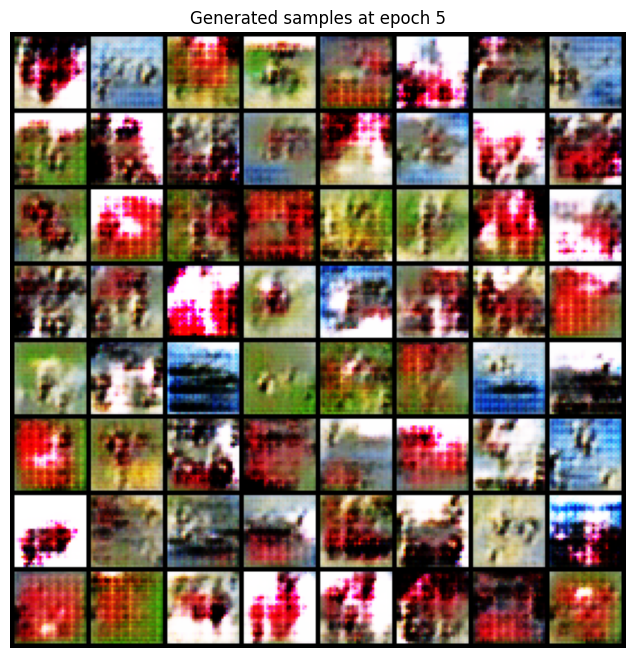

Epoch 006/10 | G loss: 1.7647 | D loss: 0.5852
Epoch 007/10 | G loss: 1.6693 | D loss: 0.5818
Epoch 008/10 | G loss: 1.6685 | D loss: 0.5874
Epoch 009/10 | G loss: 1.6844 | D loss: 0.5675
Epoch 010/10 | G loss: 1.7156 | D loss: 0.5537


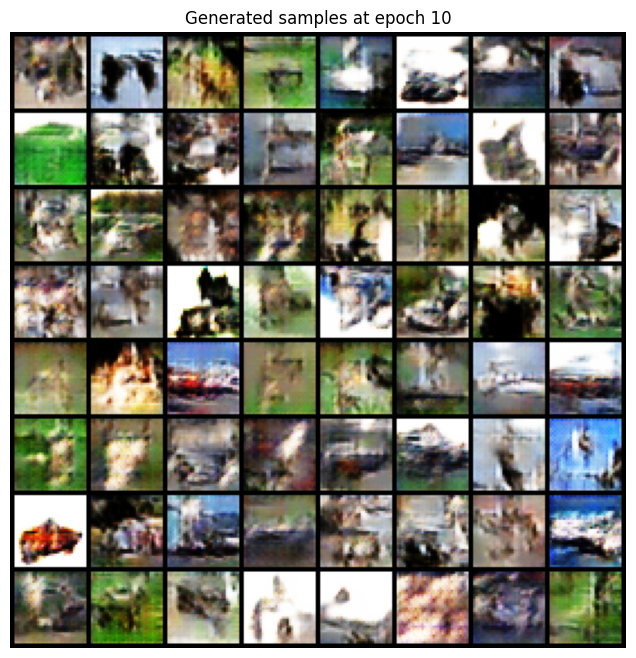

Saved checkpoint to: cifar10_gan_runs_notebook\checkpoint_epoch_010.pt
Training finished.
Metrics saved to: cifar10_gan_runs_notebook\metrics.csv


In [11]:
# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
# Training alternates between two updates:
# 1. Update the discriminator so it can better separate real from fake.
# 2. Update the generator so it can better fool the discriminator.
#
# We also use one-sided label smoothing for real images by replacing
# target value 1.0 with 0.9. This is a small stabilization trick that
# can make the discriminator a bit less overconfident.

generator_losses = []
discriminator_losses = []

with METRICS_PATH.open("w", newline="") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["epoch", "generator_loss", "discriminator_loss"])

    for epoch in range(1, EPOCHS + 1):
        generator_loss_total = 0.0
        discriminator_loss_total = 0.0

        for real_images, _ in train_loader:
            # Move the real images to the selected device.
            real_images = real_images.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
            batch_size = real_images.size(0)

            # Real images use smoothed labels; fake images use 0.0.
            real_targets = torch.full((batch_size, 1), 0.9, device=DEVICE)
            fake_targets = torch.zeros((batch_size, 1), device=DEVICE)

            # ----------------------------------------------------
            # 1. Train the discriminator
            # ----------------------------------------------------
            d_optimizer.zero_grad(set_to_none=True)

            # Discriminator loss on real images.
            real_logits = discriminator(real_images)
            real_loss = criterion(real_logits, real_targets)

            # Generate a batch of fake images from random noise.
            noise = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
            fake_images = generator(noise)

            # Detach fake_images so discriminator training does not
            # backpropagate into the generator during this step.
            fake_logits = discriminator(fake_images.detach())
            fake_loss = criterion(fake_logits, fake_targets)

            discriminator_loss = 0.5 * (real_loss + fake_loss)
            discriminator_loss.backward()
            d_optimizer.step()

            # ----------------------------------------------------
            # 2. Train the generator
            # ----------------------------------------------------
            g_optimizer.zero_grad(set_to_none=True)

            # Now we want fake images to be classified like real ones.
            generated_logits = discriminator(fake_images)
            generator_loss = criterion(generated_logits, real_targets)
            generator_loss.backward()
            g_optimizer.step()

            discriminator_loss_total += discriminator_loss.item()
            generator_loss_total += generator_loss.item()

        average_generator_loss = generator_loss_total / len(train_loader)
        average_discriminator_loss = discriminator_loss_total / len(train_loader)

        generator_losses.append(average_generator_loss)
        discriminator_losses.append(average_discriminator_loss)
        writer.writerow([epoch, average_generator_loss, average_discriminator_loss])
        csv_file.flush()

        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"G loss: {average_generator_loss:.4f} | "
            f"D loss: {average_discriminator_loss:.4f}"
        )

        if epoch % SAMPLE_EVERY == 0 or epoch == EPOCHS:
            save_sample_grid(epoch)
            show_latest_samples(epoch)

        if epoch % CHECKPOINT_EVERY == 0 or epoch == EPOCHS:
            checkpoint = {
                "epoch": epoch,
                "generator": generator.state_dict(),
                "discriminator": discriminator.state_dict(),
                "g_optimizer": g_optimizer.state_dict(),
                "d_optimizer": d_optimizer.state_dict(),
            }
            checkpoint_path = OUTPUT_DIR / f"checkpoint_epoch_{epoch:03d}.pt"
            torch.save(checkpoint, checkpoint_path)
            print("Saved checkpoint to:", checkpoint_path)

print("Training finished.")
print("Metrics saved to:", METRICS_PATH)


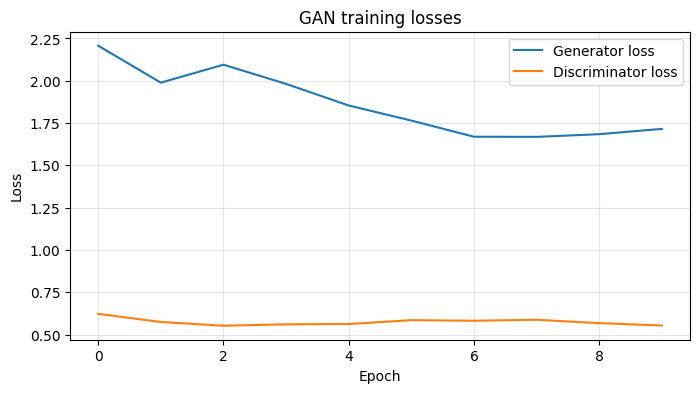

In [12]:
# ------------------------------------------------------------
# Plot the training losses
# ------------------------------------------------------------
# GAN losses can be noisy, but plotting them still helps identify
# obvious instability such as one network overpowering the other.

plt.figure(figsize=(8, 4))
plt.plot(generator_losses, label="Generator loss")
plt.plot(discriminator_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN training losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ------------------------------------------------------------
# Calculate FID score
# ------------------------------------------------------------
# Fréchet Inception Distance compares statistics of real-image features
# and generated-image features. Lower is better.
#
# This block uses pretrained Inception-v3 features. The first time you
# run it, torchvision may download pretrained weights if they are not
# already cached on your machine.

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


@torch.no_grad()
def preprocess_for_inception(images):
    # Convert GAN training images from [-1, 1] back to [0, 1].
    images = (images + 1.0) / 2.0
    images = images.clamp(0.0, 1.0)

    # Inception-v3 expects larger inputs, so we resize to 299x299.
    images = F.interpolate(images, size=(299, 299), mode="bilinear", align_corners=False)

    # Normalize with ImageNet statistics because the pretrained model
    # was trained under that convention.
    mean = IMAGENET_MEAN.to(images.device)
    std = IMAGENET_STD.to(images.device)
    return (images - mean) / std


@torch.no_grad()
def extract_inception_features(model, images):
    processed_images = preprocess_for_inception(images)
    features = model(processed_images)

    # After replacing the classifier with Identity, Inception returns
    # a 2048-dimensional feature vector for each image.
    if features.ndim > 2:
        features = torch.flatten(features, start_dim=1)
    return features


def compute_feature_statistics(features):
    # Use float64 for the covariance computation to reduce numerical
    # error in the matrix operations used by FID.
    features = features.to(torch.float64)
    mean = features.mean(dim=0)
    centered = features - mean
    covariance = centered.T @ centered / (features.size(0) - 1)
    return mean, covariance


def trace_sqrt_product(covariance_real, covariance_fake, eps=1e-6):
    # FID needs trace(sqrt(Sigma_real * Sigma_fake)). Directly taking a
    # matrix square root of the product can be numerically awkward.
    #
    # A more stable alternative is:
    # trace(sqrt(Sigma_real * Sigma_fake))
    # = trace(sqrt(sqrt(Sigma_real) * Sigma_fake * sqrt(Sigma_real)))
    feature_dim = covariance_real.size(0)
    identity = torch.eye(feature_dim, dtype=covariance_real.dtype)

    covariance_real = covariance_real + eps * identity
    covariance_fake = covariance_fake + eps * identity

    eigenvalues_real, eigenvectors_real = torch.linalg.eigh(covariance_real)
    eigenvalues_real = torch.clamp(eigenvalues_real, min=0.0)

    sqrt_covariance_real = (
        eigenvectors_real
        @ torch.diag(torch.sqrt(eigenvalues_real))
        @ eigenvectors_real.T
    )

    inner_matrix = sqrt_covariance_real @ covariance_fake @ sqrt_covariance_real
    inner_matrix = 0.5 * (inner_matrix + inner_matrix.T)

    inner_eigenvalues = torch.linalg.eigvalsh(inner_matrix)
    inner_eigenvalues = torch.clamp(inner_eigenvalues, min=0.0)
    return torch.sum(torch.sqrt(inner_eigenvalues))


@torch.no_grad()
def collect_real_features(feature_model, loader, max_images):
    collected_features = []
    collected_count = 0

    for real_images, _ in loader:
        real_images = real_images.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
        batch_features = extract_inception_features(feature_model, real_images)
        batch_features = batch_features.cpu()

        remaining = max_images - collected_count
        collected_features.append(batch_features[:remaining])
        collected_count += min(len(batch_features), remaining)

        if collected_count >= max_images:
            break

    return torch.cat(collected_features, dim=0)


@torch.no_grad()
def collect_fake_features(feature_model, generator_model, max_images, batch_size):
    collected_features = []
    collected_count = 0

    generator_was_training = generator_model.training
    generator_model.eval()

    while collected_count < max_images:
        current_batch_size = min(batch_size, max_images - collected_count)
        noise = torch.randn(current_batch_size, LATENT_DIM, device=DEVICE)
        fake_images = generator_model(noise)
        batch_features = extract_inception_features(feature_model, fake_images)
        collected_features.append(batch_features.cpu())
        collected_count += current_batch_size

    if generator_was_training:
        generator_model.train()

    return torch.cat(collected_features, dim=0)


def calculate_fid(feature_model, loader, generator_model, num_images, batch_size):
    real_features = collect_real_features(feature_model, loader, num_images)
    fake_features = collect_fake_features(feature_model, generator_model, num_images, batch_size)

    mean_real, covariance_real = compute_feature_statistics(real_features)
    mean_fake, covariance_fake = compute_feature_statistics(fake_features)

    mean_difference = mean_real - mean_fake
    mean_distance = mean_difference.dot(mean_difference)
    covariance_trace = torch.trace(covariance_real) + torch.trace(covariance_fake)
    covariance_cross_term = trace_sqrt_product(covariance_real, covariance_fake)

    fid_value = mean_distance + covariance_trace - 2.0 * covariance_cross_term
    return float(fid_value.item())


images_for_fid = min(FID_NUM_IMAGES, len(train_loader.dataset))
print(f"Calculating FID using {images_for_fid} real images and {images_for_fid} generated images...")

fid_feature_model = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False).to(DEVICE)
fid_feature_model.fc = nn.Identity()
fid_feature_model.eval()

fid_score = calculate_fid(
    feature_model=fid_feature_model,
    loader=train_loader,
    generator_model=generator,
    num_images=images_for_fid,
    batch_size=FID_BATCH_SIZE,
)

print(f"FID score: {fid_score:.4f}")

Calculating FID using 5000 real images and 5000 generated images...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\sarah/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:05<00:00, 21.5MB/s] 


In [ ]:
# ------------------------------------------------------------
# Save one final checkpoint explicitly
# ------------------------------------------------------------
# This cell is useful if you stop training early and still want a
# final snapshot of the current model weights.

final_checkpoint = {
    "epoch": EPOCHS,
    "generator": generator.state_dict(),
    "discriminator": discriminator.state_dict(),
    "g_optimizer": g_optimizer.state_dict(),
    "d_optimizer": d_optimizer.state_dict(),
}

final_checkpoint_path = OUTPUT_DIR / "checkpoint_final.pt"
torch.save(final_checkpoint, final_checkpoint_path)
print("Saved final checkpoint to:", final_checkpoint_path)

### Short written questions

1. Why do we normalize CIFAR-10 images to the range [-1, 1] in this notebook?
2. Why do we detach fake images when training the discriminator?
3. After training, what do the generated images look like in the early epochs versus the later epochs?
